# EDX acquisition notebook
- Params default values
    - dispersion 10eV per channel
    - Offset = -250
    - exposure 1 second

## 1. Initial steps:
- out folder name
- imports
- initiate ip and por tof microsope
- connect 

In [217]:
from stemOrchestrator.logging_config import setup_logging
import os
import time
from datetime import datetime

data_folder = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_stem_edx_{int(time.time())}/"
print(data_folder)
os.makedirs(data_folder, exist_ok=True)
out_path = data_folder
setup_logging(out_path=out_path)

20260228_144739_stem_edx_1772308059/


In [218]:
from stemOrchestrator.acquisition import TFacquisition, DMacquisition
from stemOrchestrator.simulation import DMtwin
from stemOrchestrator.process import HAADF_tiff_to_png, tiff_to_png
from autoscript_tem_microscope_client import TemMicroscopeClient
import matplotlib.pyplot as plt
import logging

plot = plt
from typing import Dict

In [219]:
import os
import json
from pathlib import Path

ip = os.getenv("MICROSCOPE_IP")
port = os.getenv("MICROSCOPE_PORT")

if not ip or not port:
    secret_path = Path("../../config_secret.json")
    if secret_path.exists():
        with open(secret_path, "r") as f:
            secret = json.load(f)
            ip = ip or secret.get("ip_TF")
            port = port or secret.get("port_TF")


if ip is None:
    print("please check path of yaml file containing ip and port info")

else:
    print("your yaml file with ip and port loaded fine")
config = {
    "ip": ip,
    "port": port,
    "haadf_exposure": 10e-6,  # micro-seconds per pixel
    "haadf_resolution": 1024,  # square
    "out_path": f"{data_folder}",
}

your yaml file with ip and port loaded fine


In [220]:
ip = config["ip"]
port = config["port"]
haadf_exposure = config["haadf_exposure"]
out_path = config["out_path"]
haadf_resolution = config["haadf_resolution"]


microscope = TemMicroscopeClient()
microscope.connect(ip, port=port)  # 7521 on velox  computer
# microscope.connect( port = port)# 7521 on velox  computer

# query state:

tf_acquisition = TFacquisition(microscope=microscope)

# put beam shift to 0,0
# tf_acquisition.move_beam_shift_positon([0, 0])

Client connecting to [10.46.217.241:9095]...
Client connected to [10.46.217.241:9095]
2026-02-28 14:47:55,614 - INFO - Starting microscope initialization...
2026-02-28 14:47:55,627 - INFO - CETA camera initialized
2026-02-28 14:47:55,631 - INFO - HAADF detector initialized
2026-02-28 14:47:55,637 - INFO - Microscope initialization completed successfully


## 2. Get HAADF

2026-02-28 14:47:56,031 - INFO - Acquiring HAADF image.
2026-02-28 14:47:56,031 - INFO - Performing beam UNblanking (old method)
2026-02-28 14:47:56,033 - INFO - DONE -- beam UNblanking
2026-02-28 14:48:08,130 - INFO - Performing beam blanking (old method)
2026-02-28 14:48:08,144 - INFO - DONE -- beam blanking
2026-02-28 14:48:09,335 - INFO - saving HAADF image as TF which has all the metadata..also returning an array
2026-02-28 14:48:09,335 - INFO - Done: Acquiring HAADF image - beam is blanked after acquisition - HAADF det is inserted


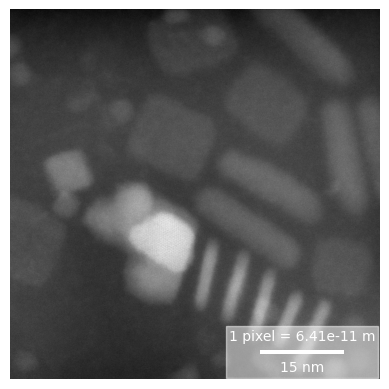

In [221]:
# get haadf from mic

# Get haadf
haadf_np_array, haadf_tiff_name = tf_acquisition.acquire_haadf(
    exposure=haadf_exposure, resolution=haadf_resolution, folder_path=out_path
)

HAADF_tiff_to_png(out_path + haadf_tiff_name)
haadf = haadf_np_array

W, H = haadf.shape

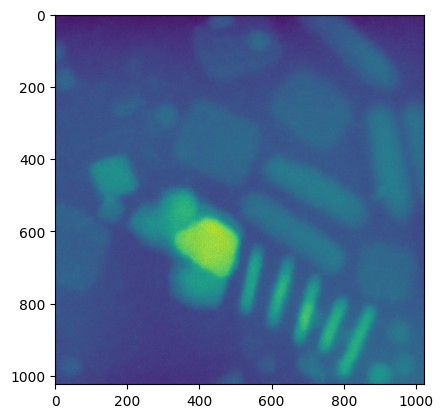

In [222]:
# best haadf after normalization
haadf_normalized = haadf_np_array

plt.imshow(haadf_normalized)

## 3. Run SAM on the HAADF

In [223]:
## get positons from sam

########SAM part ********************************************************************************************************
# -----> takes quite some time- 3 minutes-- to load --
from stemOrchestrator.MLlayer.MLlayerSAM import (
    setup_device,
    download_sam_model,
    initialize_sam_model,
    preprocess_image,
    generate_and_save_masks,
    create_normalized_particle_positions,
    display_image_with_masks,
    display_image_with_labels,
    extract_mask_contours,
    generate_mask_colors,
    visualize_masks_with_boundaries,
    extract_particle_data,
    print_boundary_points_info,
    plot_centroids,
    sample_particle_positions,
    plot_sampled_positions,
    create_visualization_with_masks,
)
import pickle
import numpy as np
from typing import List, Dict, Union


def run_sam(image_data: np.ndarray, path_folder: str) -> Union[List, Dict]:
    """Main function to run SAM segmentation pipeline."""
    device = setup_device()

    model_type = "vit_h"#"vit_b"  # Options: 'vit_b', 'vit_l', 'vit_h'
    checkpoint_url = (
        # "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    )
    checkpoint_path = "sam_vit_h_4b8939.pth"
    download_sam_model(model_type, checkpoint_url, checkpoint_path)
    sam, mask_generator = initialize_sam_model(model_type, checkpoint_path, device)
    img_np = preprocess_image(image_data)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

    # Generate and visualize masks
    masks_path = f"{path_folder}/masks_Au_online.pkl"
    masks = generate_and_save_masks(mask_generator, img_np, masks_path)
    visual_image, centroids = create_visualization_with_masks(img_np, masks)
    display_image_with_masks(visual_image, "Image with Segmentation Masks")
    display_image_with_labels(
        visual_image, centroids, "Image with Segmentation Masks and Labels"
    )

    mask_contours = extract_mask_contours(masks)
    mask_colors = generate_mask_colors(len(masks))
    boundaries_path = (
        f"{path_folder}/Segmentation Masks with Boundaries and Centroids.png"
    )
    visualize_masks_with_boundaries(
        visual_image, centroids, mask_contours, mask_colors, boundaries_path
    )
    particles = extract_particle_data(masks)
    # Save particle data
    # with open(f'{path_folder}/particles.pkl', 'wb') as f:
    #     pickle.dump(particles, f)

    print_boundary_points_info(particles)
    centroids_array = np.array(centroids)
    plot_centroids(centroids_array, img_np)
    positions_sampled = sample_particle_positions(particles, img_np)
    plot_sampled_positions(positions_sampled, img_np, len(centroids))
    each_particle_position = create_normalized_particle_positions(
        particles, img_np.shape[:2]
    )
    # with open(f'{path_folder}/sampled_boundary_pts_particles.pkl', 'wb') as f: # Save normalized particle positions
    #     pickle.dump(each_particle_position, f)

    all_particle_keys = each_particle_position.keys()

    print("Processing complete!")
    return all_particle_keys, each_particle_position


##########****************************************************************************************************************************

20260228_144811
Using device: cuda
SAM model checkpoint already exists.


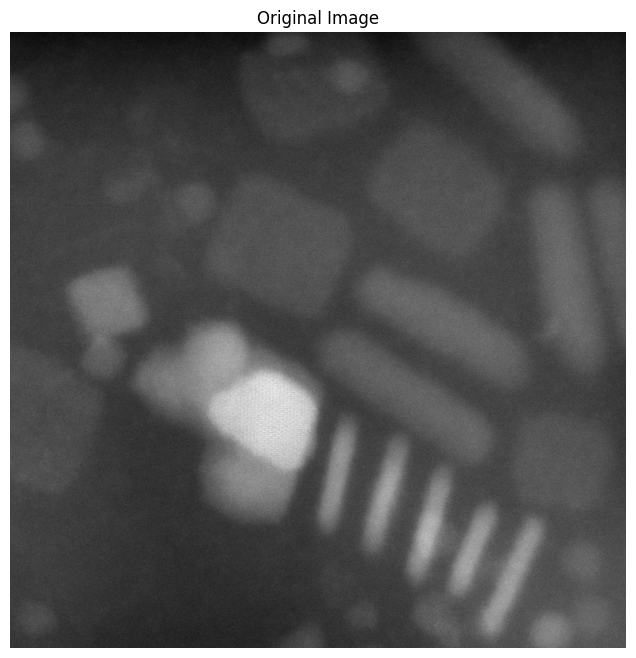

Generating masks...
Number of masks generated: 37
2026-02-28 14:48:31,689 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.039215688..451.39215].


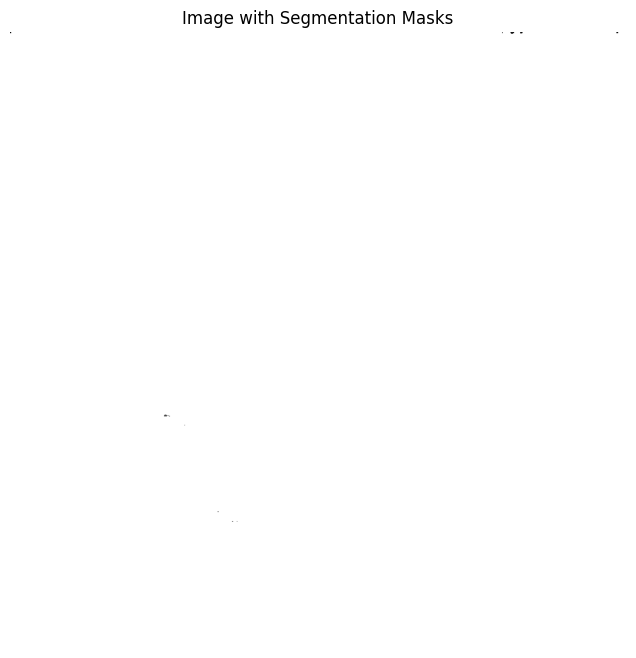

2026-02-28 14:48:31,879 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.039215688..451.39215].


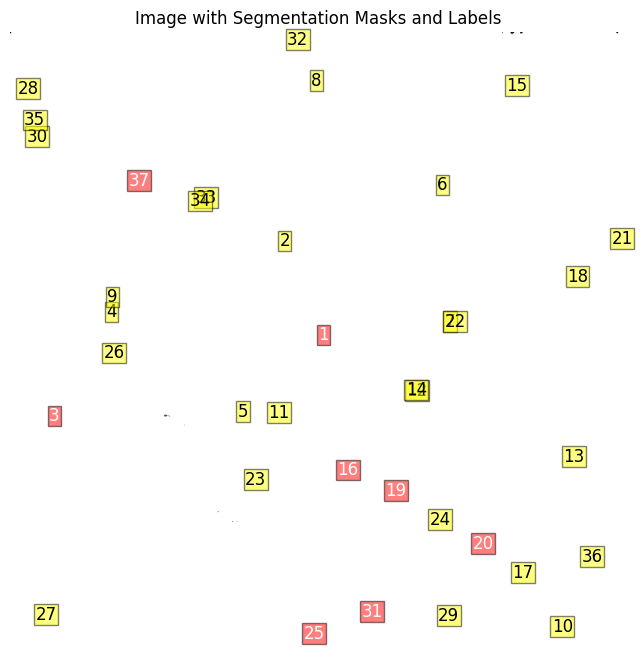

Extracted contours for 37 masks.
2026-02-28 14:48:32,279 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.039215688..451.39215].
Total particles stored: 37
Boundary Points per Particle:
-----------------------------
Particle 1: 4 boundary points
Particle 2: 10 boundary points
Particle 3: 7 boundary points
Particle 4: 14 boundary points
Particle 5: 11 boundary points
Particle 6: 10 boundary points
Particle 7: 8 boundary points
Particle 8: 11 boundary points
Particle 9: 9 boundary points
Particle 10: 10 boundary points
Particle 11: 11 boundary points
Particle 12: 10 boundary points
Particle 13: 11 boundary points
Particle 14: 11 boundary points
Particle 15: 9 boundary points
Particle 16: 9 boundary points
Particle 17: 9 boundary points
Particle 18: 10 boundary points
Particle 19: 11 boundary points
Particle 20: 9 boundary points
Particle 21: 6 boundary points
Particle 22: 8 boundary points
Particle 23: 

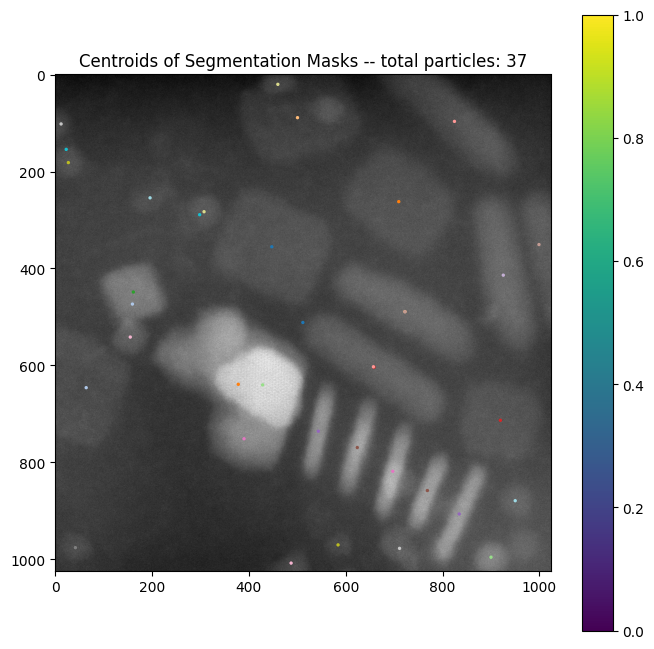

Positions array shape: (395, 3)


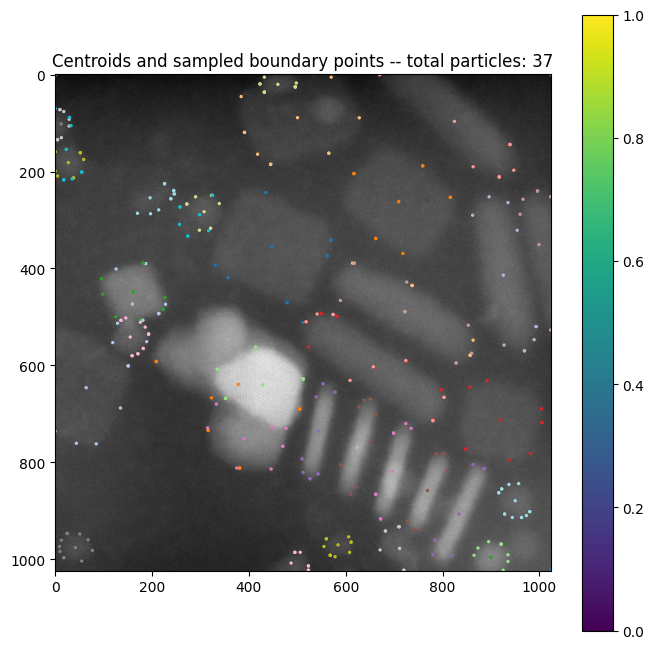

Processing complete!
20260228_144833


In [224]:
## run the segmentaiotn on haadf to get particles
from datetime import datetime

print(datetime.now().strftime("%Y%m%d_%H%M%S"))
all_particle_keys, each_particle_position = run_sam(
    haadf_np_array, out_path
)  ############ haadf normalized doesnt work here --- weird
print(datetime.now().strftime("%Y%m%d_%H%M%S"))

## 4. Save postions of identified objects in SAM

In [225]:
# finds positions to sample from
# N = 20
rng = np.random.default_rng(42)
# xs = rng.integers(0, W, size=N)
# ys = rng.integers(0, H, size=N)
# pixel_pos = np.stack([xs, ys], axis=1)

centroids = np.array([v["centroid"] for v in each_particle_position.values()])

# Sample N random centroids (without replacement if fewer than N)
N = len(centroids)
rng = np.random.default_rng(42)
idx = rng.choice(len(centroids), size=min(N, len(centroids)), replace=False)
sampled = centroids[idx]

# Separate xs and ys (keeping same data types as your original code)
xs = sampled[:, 0] * W
ys = sampled[:, 1] * H
pixel_pos = np.stack([xs, ys], axis=1)

print("xs:", xs)
print("ys:", ys)
print("pixel_pos:\n", pixel_pos)

np.save(f"{out_path}pixel_pos.npy", pixel_pos)

xs: [ 41.92362843 949.92940039 307.52796255 711.11935981 390.08500187
 998.99325017 722.32994161 543.48332669 159.62793323 657.17842612
 584.2113857  161.56383862 824.50869497 196.07390817 658.27678224
  64.20959462 155.17649791 511.51055823 768.62612258  22.99264706
 500.4665181  378.20052796 925.27027898 623.81683411 834.32005463
 697.15936409 919.31472881  12.36411264 447.41351111 428.504043
 298.42960715 487.25229961 709.4417596  722.32721356 899.94732465
  27.37706368 459.8990755 ]
ys: [ 976.29738155  879.40667311  282.76841587  977.79232549  751.55241885
  350.58433014  488.9825868   735.97396041  473.42891938  602.8956428
  970.62312445  448.60725552   96.29727401  254.13594625  603.75470965
  646.09470703  541.56641895  511.49338215  858.38191271  154.06339869
   88.60875426  639.08647308  413.74408194  769.62876746  906.77407239
  818.68605403  713.35648247  101.59593975  355.18379683  640.35202626
  288.91468555 1008.18878668  261.93954682  489.29419421  996.06404214
  181.32

## 6. Setup EDX acquisiton

In [226]:
## setup edx acquire
import xmltodict
import json
from autoscript_tem_microscope_client.structures import EdsAcquisitionSettings
from autoscript_tem_microscope_client.enumerations import (
    EdsDetectorType,
    ExposureTimeType,
)


def get_channel_index(energy_keV: float, dispersion: float, offset: float) -> int:
    """Convert energy (keV) into spectrum channel index."""
    return int(round((energy_keV - offset) / dispersion))


def get_dispersion_and_offset(spectrum):
    """
    Extract dispersion and offset from EDS spectrum metadata (xml).
    Returns (dispersion_keV_per_ch, offset_keV).
    """
    xml_string = spectrum.metadata.metadata_as_xml
    metadata = xmltodict.parse(xml_string)
    metadata = json.loads(json.dumps(metadata))

    detectors = metadata["Metadata"]["Detectors"]["AnalyticalDetector"]

    # If only one detector, wrap it into a list
    if isinstance(detectors, dict):
        detectors = [detectors]

    # Take the first detector (or filter by name if needed)
    det = detectors[0]
    dispersion = float(det.get("Dispersion", 0))
    offset = float(det.get("OffsetEnergy", 0))

    return dispersion, offset


def configure_acquisition(exposure_time=2):
    """Configure the EDS acquisition settings."""
    # mic_server is global variable intriduced in def run function
    eds_detector_name = microscope.detectors.eds_detectors[0]
    eds_detector = microscope.detectors.get_eds_detector(eds_detector_name)
    # Configure the acquisition
    global eds_settings
    eds_settings = EdsAcquisitionSettings()
    eds_settings.eds_detector = eds_detector_name
    eds_settings.dispersion = eds_detector.dispersions[-2]  # 10 keV
    eds_settings.shaping_time = eds_detector.shaping_times[-1]
    eds_settings.exposure_time = exposure_time
    eds_settings.exposure_time_type = ExposureTimeType.LIVE_TIME
    return eds_settings

## 7. Acquire EDX

In [227]:
# get edx at those positon and stack them
# 2 minutes for 20 points
edx_exposure = 1  # in seconds
eds_settings = configure_acquisition(exposure_time=edx_exposure)

all_arrays = []  # 1. Create an empty list before the loop
for point in pixel_pos:
    print("only doing 10 points")
    # convert to fractional coordinates
    x_pos = point[0] / W
    y_pos = point[1] / H

    # position beam
    tf_acquisition.move_paused_beam(x_pos, y_pos)

    # Acquire the EDS spectrum
    microscope.optics.blanker.unblank()
    spectrum = microscope.analysis.eds.acquire_spectrum(eds_settings)
    microscope.optics.blanker.blank()

    # # Average spectrum data from 4 detectors
    # n_channels_per_detector = len(spectrum.data) // 4
    # summed_spectrum = np.zeros(n_channels_per_detector)

    # for i in range(4):
    #     start_idx = i * n_channels_per_detector
    #     end_idx = (i + 1) * n_channels_per_detector
    #     summed_spectrum += spectrum.data[start_idx:end_idx]

    # # Use summed spectrum for analysis
    # spectrum_data = summed_spectrum
    
    ##############
    # #lets not sum
    #########
    spectrum_data = spectrum.data

    # stack the arrays
    all_arrays.append(spectrum_data)  # 2. Add the new array to the list

spectra = np.stack(all_arrays, axis=0)
print(spectra.shape)

only doing 10 points
2026-02-28 14:48:33,601 - INFO - Set beam position: old Point(x=-0.125, y=1.125)
2026-02-28 14:48:33,619 - INFO - UPDATED beam position: NewPoint(x=0.040941045, y=0.95341539)
only doing 10 points
2026-02-28 14:48:35,724 - INFO - Set beam position: old Point(x=0.040941045, y=0.95341539)
2026-02-28 14:48:35,743 - INFO - UPDATED beam position: NewPoint(x=0.92766541, y=0.85879558)
only doing 10 points
2026-02-28 14:48:37,600 - INFO - Set beam position: old Point(x=0.92766541, y=0.85879558)
2026-02-28 14:48:37,620 - INFO - UPDATED beam position: NewPoint(x=0.30032027, y=0.27614102)
only doing 10 points
2026-02-28 14:48:39,449 - INFO - Set beam position: old Point(x=0.30032027, y=0.27614102)
2026-02-28 14:48:39,469 - INFO - UPDATED beam position: NewPoint(x=0.69445252, y=0.95487529)
only doing 10 points
2026-02-28 14:48:41,311 - INFO - Set beam position: old Point(x=0.69445252, y=0.95487529)
2026-02-28 14:48:41,331 - INFO - UPDATED beam position: NewPoint(x=0.38094237, y

## 8. Save collected edx on disk

In [228]:
# normalize the spectra
# Optional: normalize spectra (safe min-max per spectrum)
mins = spectra.min(axis=1, keepdims=True)
ptps = np.ptp(spectra, axis=1, keepdims=True)
ptps = np.where(ptps == 0, 1.0, ptps)
spectra_norm = (spectra - mins) / ptps
np.save(f"{out_path}raw_spectra.npy", spectra)
# save raw spectra
np.save(f"{out_path}normalized_spectra.npy",spectra_norm)

## 9. Lets get more than just centroids 

In [ ]:
import numpy as np

def sample_points_left_from_centroids(
    centroids_rel, W, H, n=6, max_shift_px=10, seed=42
):
    """
    centroids_rel: (M, 2) in RELATIVE coords [0..1] (x_rel, y_rel)
    returns pixel_pos: (M*n, 2) in pixel coords (x_px, y_px)
    """
    centroids_px = centroids_rel * np.array([W, H], dtype=float)

    shifts = np.linspace(0, max_shift_px, n)  # includes 0 (center)
    offsets = np.stack([-shifts, np.zeros_like(shifts)], axis=1)  # (n, 2): left only

    pixel_pos = (centroids_px[:, None, :] + offsets[None, :, :]).reshape(-1, 2)

    # clip to image bounds
    pixel_pos[:, 0] = np.clip(pixel_pos[:, 0], 0, W - 1)
    pixel_pos[:, 1] = np.clip(pixel_pos[:, 1], 0, H - 1)

    return pixel_pos



In [ ]:
# ---- your centroids ----
centroids_rel = np.array([v["centroid"] for v in each_particle_position.values()])  # (M,2) in [0..1]

# optional: sample subset of centroids (keep your pattern)
N = len(centroids_rel)
rng = np.random.default_rng(42)
idx = rng.choice(len(centroids_rel), size=min(N, len(centroids_rel)), replace=False)
sampled_rel = centroids_rel[idx]

# ---- make positions: center + n-1 points to the left ----
W = H = haadf.shape[0]
pixel_pos = sample_points_left_from_centroids(sampled_rel, W, H, n=3, max_shift_px=10)

np.save(f"{out_path}pixel_pos.npy", pixel_pos)

print("pixel_pos shape:", pixel_pos.shape)   # (num_centroids * n, 2)
print(pixel_pos[:10])

In [ ]:
import numpy as np

def collect_edx_for_particles(
    *,
    microscope,
    tf_acquisition,
    configure_acquisition,
    pixel_pos,              # (M*n, 2) pixel coords, ordered per particle
    centroid_pixel_pos,     # (M, 2) pixel coords
    W,
    H,
    n_per_particle=6,
    edx_exposure=1.0,
    max_points=None,        # optional debug limit (e.g., 10)
):
    eds_settings = configure_acquisition(exposure_time=edx_exposure)

    all_arrays = []
    pts = pixel_pos if max_points is None else pixel_pos[:max_points]

    for point in pts:
        x_pos = float(point[0]) / W
        y_pos = float(point[1]) / H

        tf_acquisition.move_paused_beam(x_pos, y_pos)

        microscope.optics.blanker.unblank()
        try:
            spectrum = microscope.analysis.eds.acquire_spectrum(eds_settings)
            spectrum_data = np.asarray(spectrum.data)
        finally:
            microscope.optics.blanker.blank()

        all_arrays.append(spectrum_data)

    spectra = np.stack(all_arrays, axis=0)  # (K, C)
    C = spectra.shape[1]

    # If you limited points for debugging, only average complete particle groups.
    M = int(len(spectra) // n_per_particle)
    spectra = spectra[: M * n_per_particle].reshape(M, n_per_particle, C)  # (M, n, C)

    averaged_spectrum = spectra.mean(axis=1)  # (M, C)

    return centroid_pixel_pos[:M], averaged_spectrum, spectra  # spectra is optional but handy

In [ ]:
# centroid pixels (same ordering as the particles you sampled)
centroid_pixel_pos = sampled_rel * np.array([W, H], dtype=float)  # (M, 2)

centroid_pixel_pos, averaged_spectrum, spectra_by_point = collect_edx_for_particles(
    microscope=microscope,
    tf_acquisition=tf_acquisition,
    configure_acquisition=configure_acquisition,
    pixel_pos=pixel_pos,
    centroid_pixel_pos=centroid_pixel_pos,
    W=W,
    H=H,
    n_per_particle=6,
    edx_exposure=1.0,
    max_points=None,   # set to 10 for quick test
)

print("centroid_pixel_pos:", centroid_pixel_pos.shape)   # (M, 2)
print("averaged_spectrum:", averaged_spectrum.shape)     # (M, C)
print("spectra_by_point:", spectra_by_point.shape)       # (M, n, C)

In [ ]:
np.save(f"{out_path}raw_spectra_averaged.npy", averaged_spectrum)
np.save(f"{out_path}raw_spectra_per_point_for_more_samples.npy", spectra_by_point)
np.save(f"{out_path}pixel_pos_centroids.npy", centroid_pixel_pos)

In [ ]:
centroid_pixel_pos

## 10. Edx quantification

### 10 a) load to sudpy data

In [229]:
import sidpy
import numpy as np
from __future__ import annotations

import pyTEMlib
from pathlib import Path
from typing import Tuple
import json
import numpy as np
import xmltodict


def sidpy_spectrum_from_disk(spectrum, dispersion_constant = 1.003) -> sidpy.Dataset:
    """
    Read saved spectrum + XML, build a sidpy.Dataset with Energy axis in eV.
    """

    dispersion = 10
    offset = -250
    # --- energy axis ---
    energy = np.arange(spectrum.shape[0], dtype=float) * dispersion*dispersion_constant + offset

    # --- sidpy dataset ---
    ds = sidpy.Dataset.from_array(spectrum)
    ds.data_type = "spectrum"
    ds.quantity = "Intensity"
    ds.units = "counts"

    ds.set_dimension(0, sidpy.Dimension(energy, name="Energy", units="eV", quantity="Energy",dimension_type='spectral'
))

    # (optional) keep raw XML around
    # ds.metadata = {"autoscript_xml_path": str(xml_path), "dispersion": dispersion, "offset": offset}

    return ds

import numpy as np

def load_edx_datasets(npy_path, dispersion_constant=1.003):
    spectra = np.load(npy_path)   # shape (N, 4096)
    print(spectra.shape)
    print(spectra.shape)
    datasets = []

    for i in range(spectra.shape[0]):
        spectrum = spectra[i]
        ds = sidpy_spectrum_from_disk(
            spectrum,              # pass 1D array
            dispersion_constant=dispersion_constant
        )
        datasets.append(ds)

    return datasets

In [230]:
npy_path = f"{out_path}raw_spectra.npy"
# npy_path = f"{out_path}raw_spectra_averaged.npy"


# xml_path = "/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/notebooks/spectrum_related/my_run/eds_0001.xml"

ds_list = load_edx_datasets(npy_path)

print(len(ds_list))


(37, 4096)
(37, 4096)
37


In [231]:

import numpy as np
import pyTEMlib

DETECTOR_META = {
    "layers": {13: {"thickness": 5e-08, "Z": 13, "element": "Al"}},
    "SiDeadThickness": 1.3e-07,
    "SiLiveThickness": 0.05,
    "detector_area": 3.0e-05,
    "energy_resolution": 125,
    "start_energy": 120,
    "ElevationAngle": 0.31415927,
    "AzimuthAngle": 3.9269908169872414,
    "RealTime": 26.2338126,
    "LiveTime": 25.20496870466589,
}

def attach_detector_metadata(ds, detector_meta=DETECTOR_META, clip_value=100.0, start_energy_key="start_energy"):
    # ensure dict structure
    ds.metadata.setdefault("EDS", {})
    ds.metadata["EDS"].setdefault("detector", {})

    # set detector meta (overwrite with provided)
    ds.metadata["EDS"]["detector"].update(detector_meta)

    # compute start channel from energy axis
    start_energy = ds.metadata["EDS"]["detector"].get(start_energy_key, 120)
    start_channel = int(np.searchsorted(ds.Energy.values, start_energy))
    ds.metadata["EDS"]["detector"]["start_channel"] = start_channel

    # compute efficiency + store
    det_eff = pyTEMlib.eds_tools.detector_response(ds)
    ds.metadata["EDS"]["detector"]["detector_efficiency"] = det_eff

    # optionally clip low-energy region
    if clip_value is not None and start_channel > 0:
        ds[:start_channel] = clip_value

    return ds

def attach_detector_metadata_many(ds_list, **kwargs):
    return [attach_detector_metadata(ds, **kwargs) for ds in ds_list]

In [232]:
ds_list = attach_detector_metadata_many(ds_list)
len(ds_list)

37

### 10 b) get elements

In [233]:
# # FInd elements
# # --------Input -----------
# minimum_number_of_peaks = 10
# # --------------------------
%matplotlib inline
# import sys
# import numpy as np
# import matplotlib.pylab as plt

# elements = pyTEMlib.eds_tools.get_elements(spectrum, minimum_number_of_peaks, verbose=False)

# plt.figure()
# plt.plot(spectrum.Energy,spectrum, label = 'spectrum')
# pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS'], plt.gca())
# plt.legend();
# plt.xlim(0,19000)
# elements
import matplotlib.pyplot as plt
import pyTEMlib

def plot_edx_spectra(ds_list, minimum_number_of_peaks=10):
    for i, spectrum in enumerate(ds_list):
        elements = pyTEMlib.eds_tools.get_elements(
            spectrum, minimum_number_of_peaks, verbose=False
        )

        plt.figure()
        plt.plot(spectrum.Energy, spectrum, label="spectrum")
        pyTEMlib.eds_tools.plot_lines(
            spectrum.metadata["EDS"], plt.gca()
        )

        plt.legend()
        plt.xlim(0, 19000)
        plt.title(f"Spectrum {i} | Elements: {elements}")
        plt.show()

In [234]:
# plot_edx_spectra(ds_list)



### 10 c) add elements?

In [235]:
import pyTEMlib

def add_elements(ds, elements):
    if isinstance(elements, str):
        elements = [elements]
    if not isinstance(elements, list):
        raise ValueError("elements must be a string or list[str]")

    ds.metadata.setdefault("EDS", {})
    ds.metadata["EDS"].update(pyTEMlib.eds_tools.get_x_ray_lines(ds, elements))
    return ds

def add_elements_many(ds_list, elements):
    return [add_elements(ds, elements) for ds in ds_list]

ds_list = add_elements_many(ds_list, ["Cd", "Se", "In", "P", "Zn", "S", "Au", "Si"])  # add Mg too if you want: ["Fe","Ni","Cr","Mg"]
# ["Cd", "Se", "In", "P", "Zn", "S", "Au"]

### 10 d) quantify each - masking can be done

In [236]:

import io
import contextlib
import pyTEMlib

def quantify_one(ds, q_dict=None, mask=("C", "F", "Ne"), use_detector_efficiency=True):
    if q_dict is None:
        q_dict = pyTEMlib.eds_tools.load_k_factors()

    # fit model (optional but you had it)
    pyTEMlib.eds_tools.fit_model(ds, use_detector_efficiency=use_detector_efficiency)

    # capture printed quantify output -> dict
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        pyTEMlib.eds_tools.quantify_eds(ds, q_dict, mask=list(mask))

    results = {}
    for line in buf.getvalue().splitlines():
        if ":" in line and "at%" in line:
            element, rest = line.split(":", 1)
            parts = rest.strip().split()
            results[element.strip()] = {"at%": float(parts[0]), "wt%": float(parts[2])}

    return results

def quantify_many(ds_list, q_dict=None, mask=("C", "F", "Ne"), use_detector_efficiency=True):
    if q_dict is None:
        q_dict = pyTEMlib.eds_tools.load_k_factors()
    return [
        quantify_one(ds, q_dict=q_dict, mask=mask, use_detector_efficiency=use_detector_efficiency)
        for ds in ds_list
    ]

In [237]:
results_list = quantify_many(ds_list)   # list[dict] (one dict per spectrum)
print(results_list[0])

{'Cd': {'at%': -10.09, 'wt%': 87.35}, 'Se': {'at%': -8.76, 'wt%': 53.29}, 'In': {'at%': -10.12, 'wt%': 89.5}, 'P': {'at%': -3.95, 'wt%': 9.43}, 'Zn': {'at%': -4.16, 'wt%': 20.95}, 'S': {'at%': 6.74, 'wt%': -16.65}, 'Au': {'at%': -10.62, 'wt%': 161.12}, 'Si': {'at%': 140.95, 'wt%': -304.99}}


In [238]:
import numpy as np
import matplotlib.pyplot as plt

def plot_edx_overlays_pretty(
    haadf,
    centroid_pixel_pos,
    results_list,
    metrics=("at%", "wt%"),
    n_cols=4,
    cmap="magma",
    clamp_to_0_100=True,
    clip_percentiles=(2, 98),
    point_size=60,
    point_alpha=0.9,
    edgecolor="white",
    linewidth=0.8,
):
    # align lengths
    N = min(len(results_list), len(centroid_pixel_pos))
    pos = np.asarray(centroid_pixel_pos)[:N]
    results_list = results_list[:N]
    xs, ys = pos[:, 0], pos[:, 1]

    # elements seen anywhere
    elements = sorted({el for r in results_list for el in r.keys()})
    panels = [(el, m) for el in elements for m in metrics]

    n_panels = len(panels)
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.6 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for k, (el, m) in enumerate(panels):
        ax = axes[k]
        ax.imshow(haadf, cmap="gray", interpolation="nearest")
        ax.set_axis_off()

        vals = np.array([r.get(el, {}).get(m, np.nan) for r in results_list], dtype=float)

        if clamp_to_0_100:
            vals = np.clip(vals, 0, 100)

        finite = vals[np.isfinite(vals)]
        if finite.size:
            vmin, vmax = np.percentile(finite, clip_percentiles)
            if np.isclose(vmin, vmax):  # avoid degenerate colorbar
                vmin, vmax = finite.min(), finite.max()
        else:
            vmin = vmax = None

        sc = ax.scatter(
            xs, ys,
            c=vals,
            s=point_size,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            alpha=point_alpha,
            edgecolors=edgecolor,
            linewidths=linewidth,
        )

        ax.set_title(f"{el} {m}", fontsize=12)
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
        cbar.ax.tick_params(labelsize=9)

    # hide unused
    for j in range(n_panels, n_rows * n_cols):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()

## 11. final plotting with haadf

In [239]:
# npy_path = f"{out_path}raw_spectra_averaged.npy"
npy_path = f"{out_path}raw_spectra.npy"



Found HAADF file: 20260228_144739_stem_edx_1772308059/HAADF_image_20260228_144756.tiff


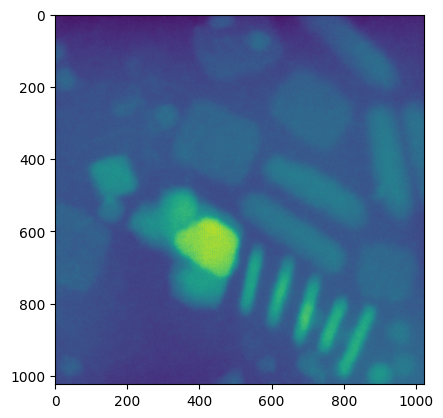

In [240]:
import numpy as np
import os

folder_path = out_path

# Find all .tiff files that contain 'haadf' in their name (case-insensitive)
haadf_files = [
    f for f in os.listdir(folder_path)
    if f.lower().endswith(".tiff") and "haadf" in f.lower()
]

# Ensure there’s exactly one match
if len(haadf_files) == 1:
    file_name = os.path.join(folder_path, haadf_files[0])
    print("Found HAADF file:", file_name)
elif len(haadf_files) == 0:
    raise FileNotFoundError("No HAADF .tiff file found in folder.")
else:
    file_name = os.path.join(folder_path, haadf_files[-1])
    raise ValueError(f"Multiple HAADF .tiff files found: {haadf_files}")

import tifffile
import matplotlib.pyplot as plt
with tifffile.TiffFile(file_name) as tif:
    haadf = tif.asarray()
    
plt.imshow(haadf)

pixel_pos = np.load(folder_path + "/" + "pixel_pos.npy")

# pixel_pos = np.load(folder_path + "/" + "pixel_pos_centroids.npy")


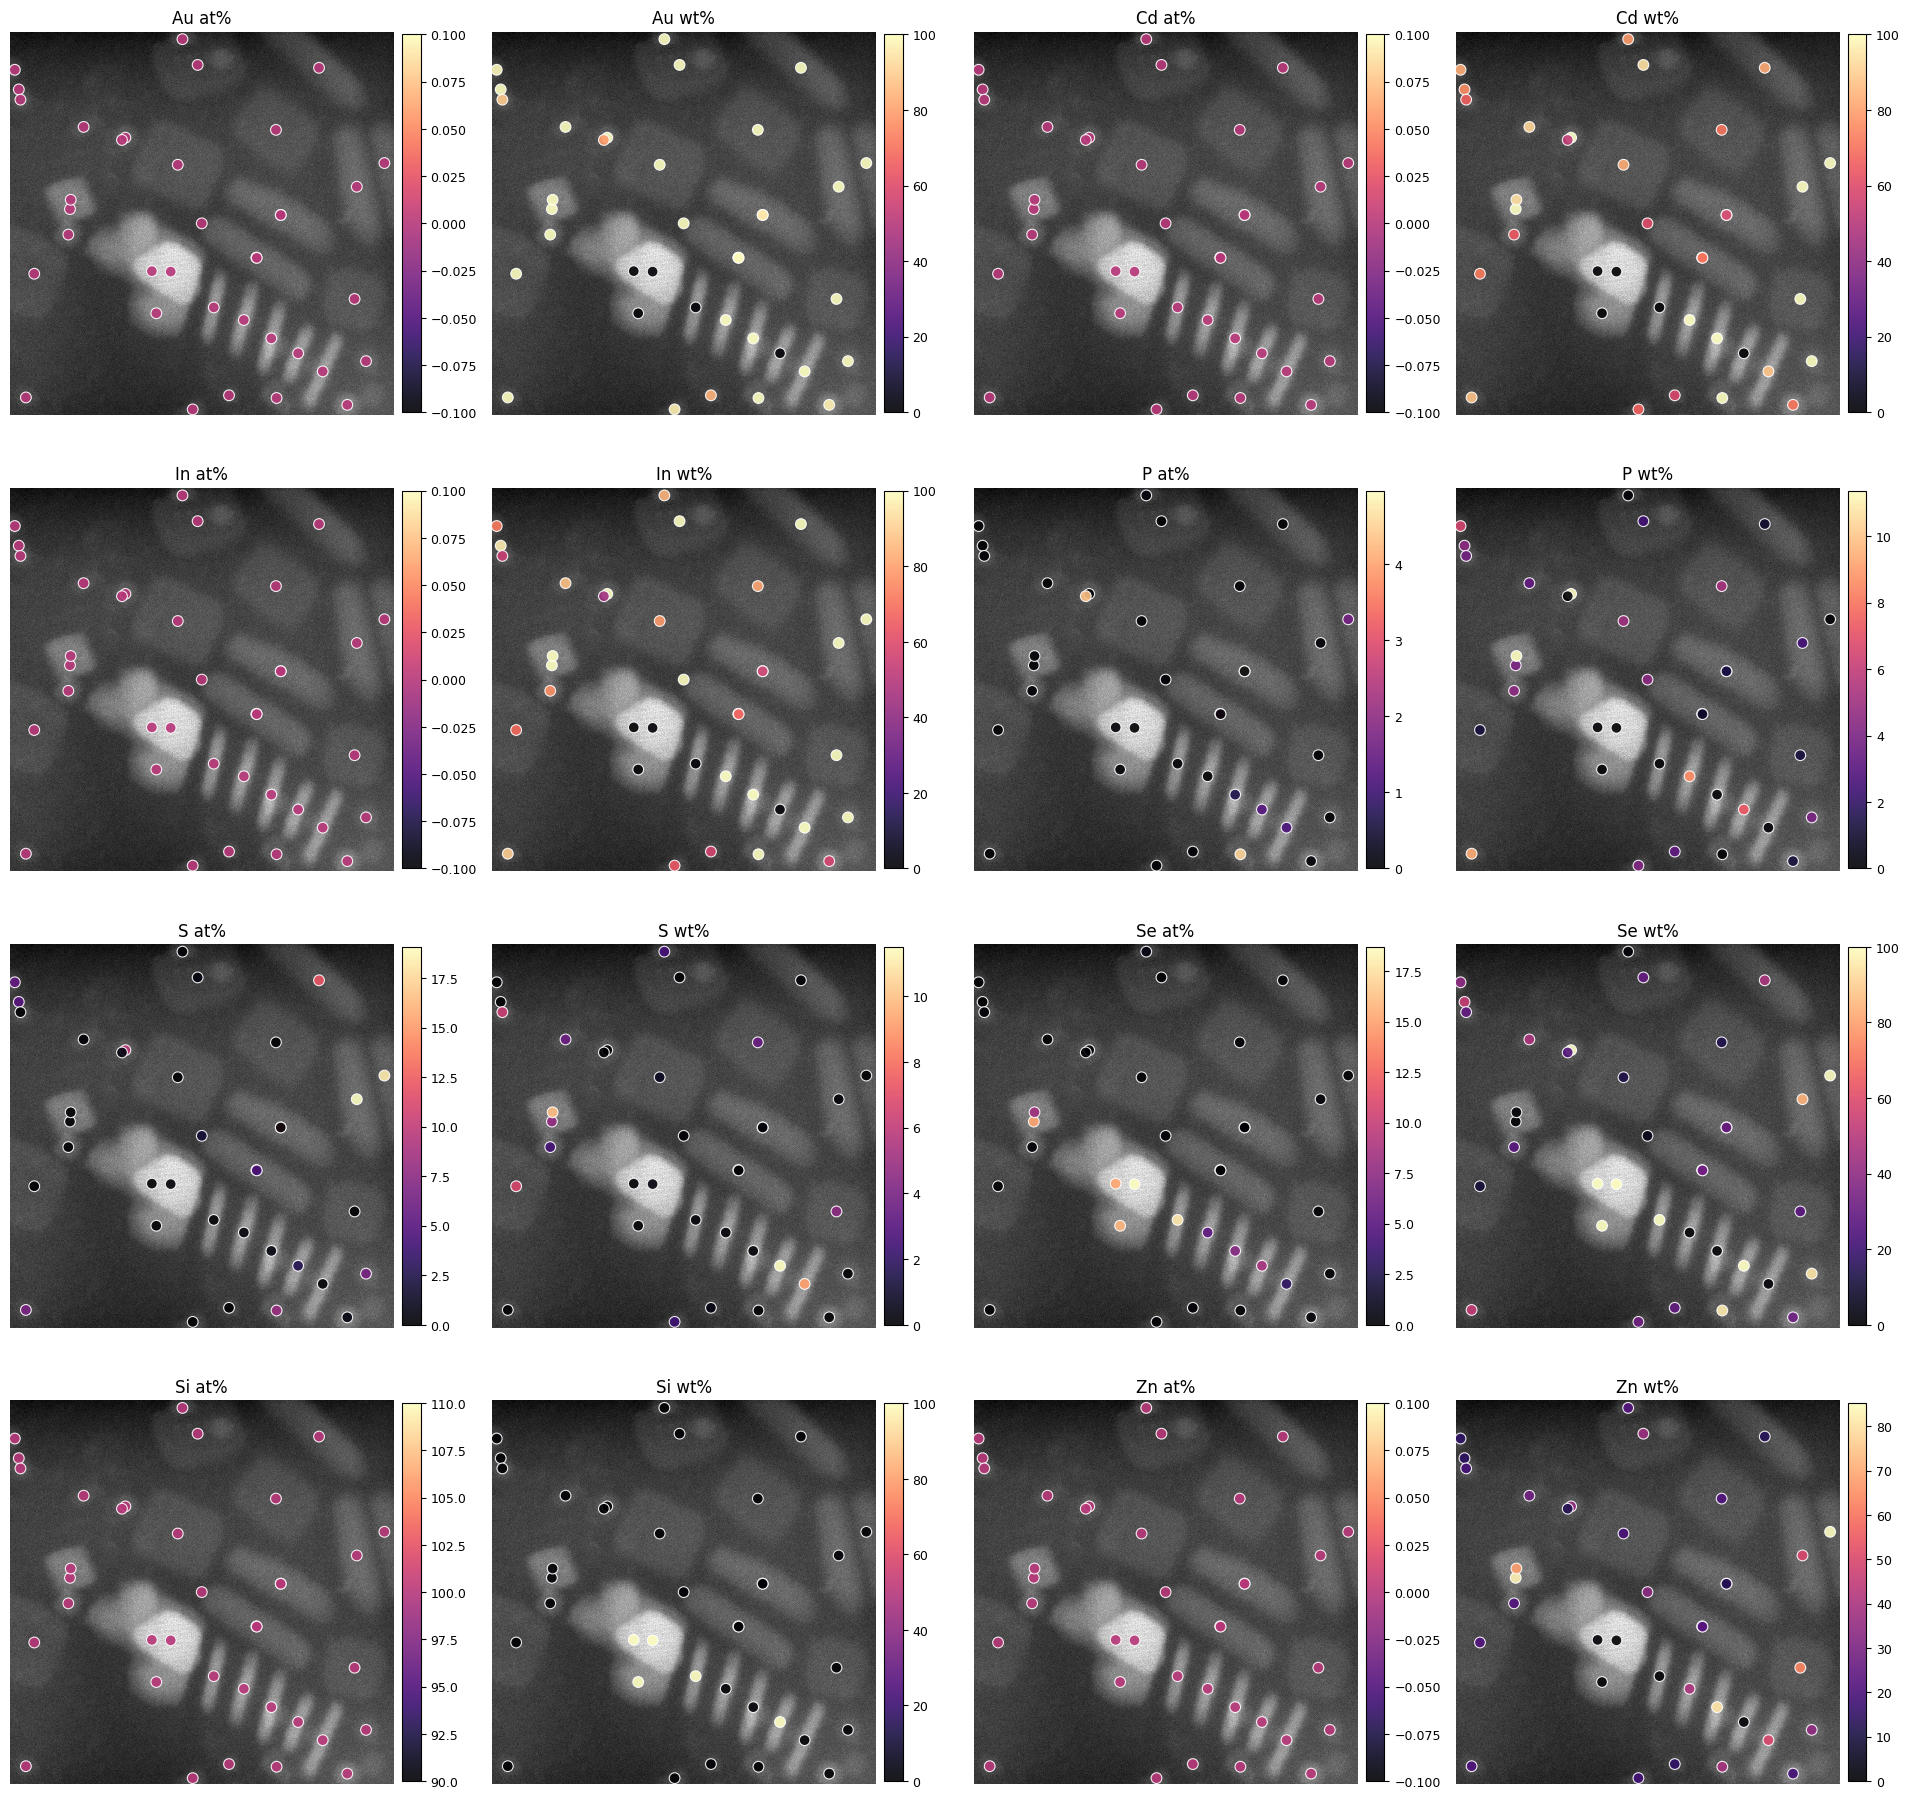

In [241]:
plot_edx_overlays_pretty(
    haadf=haadf,
    centroid_pixel_pos=pixel_pos,
    results_list=results_list,
    metrics=("at%", "wt%"),
    n_cols=4,
)